In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

train = pd.read_csv(r'C:\Users\Lenovo\Desktop\Titanic-ML\Titanic-ML\data\raw\train.csv')
test = pd.read_csv(r'C:\Users\Lenovo\Desktop\Titanic-ML\Titanic-ML\data\raw\test.csv')

print("训练集:", train.shape)
print("测试集:", test.shape)
print("\n缺失值:")
print(train.isna().sum()[train.isna().sum() > 0])

训练集: (891, 12)
测试集: (418, 11)

缺失值:
Age         177
Cabin       687
Embarked      2
dtype: int64


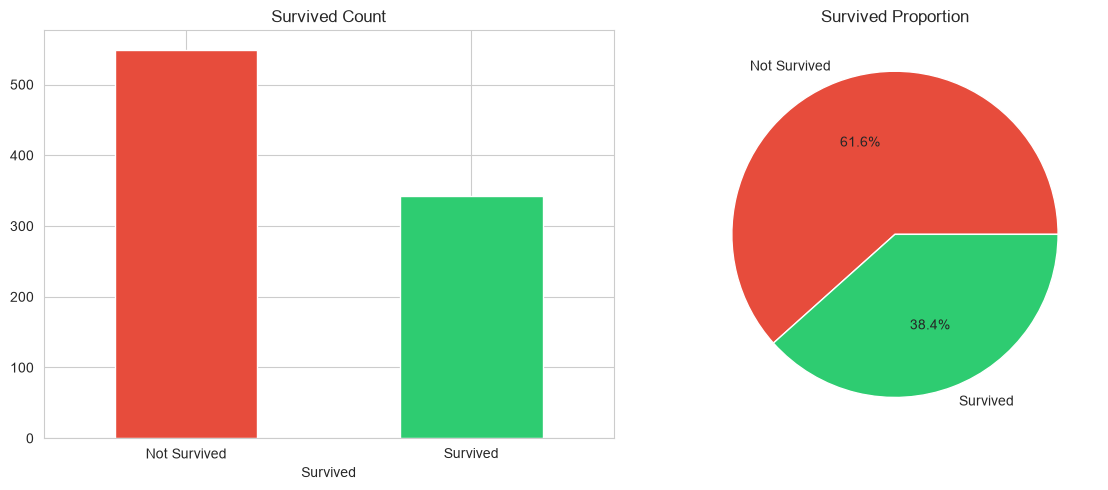

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

train['Survived'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Survived Count')
axes[0].set_xticklabels(['Not Survived', 'Survived'], rotation=0)

train['Survived'].value_counts().plot(kind='pie', ax=axes[1],
    autopct='%1.1f%%', labels=['Not Survived', 'Survived'],
    colors=['#e74c3c', '#2ecc71'])
axes[1].set_title('Survived Proportion')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_32232\477092160.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train, x='Sex', y='Survived', ax=axes[0],
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_32232\477092160.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train, x='Pclass', y='Survived', ax=axes[1],


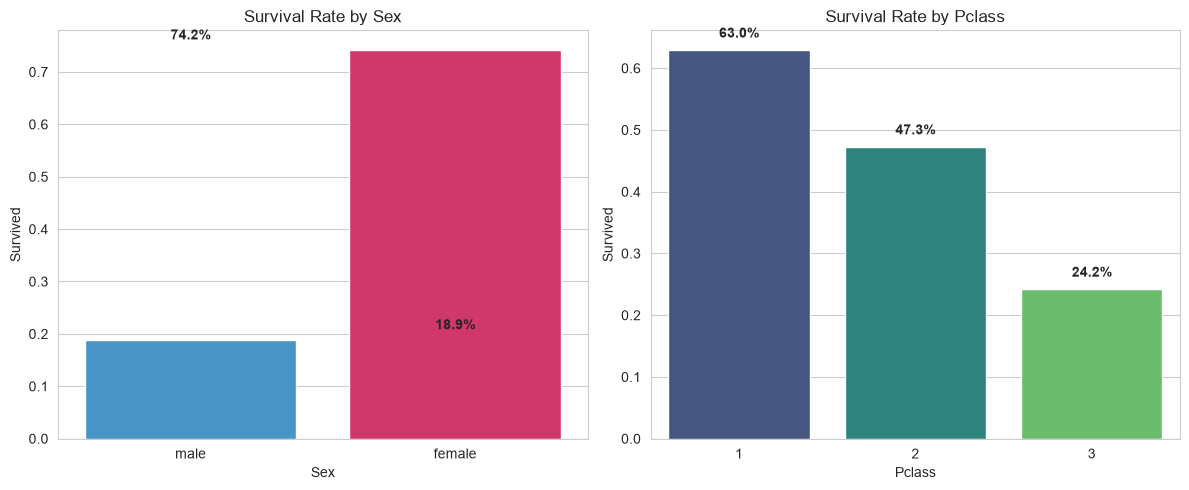

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=train, x='Sex', y='Survived', ax=axes[0],
            palette=['#3498db', '#e91e63'], errorbar=None)
axes[0].set_title('Survival Rate by Sex')

for i, v in enumerate(train.groupby('Sex')['Survived'].mean().values):
    axes[0].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

sns.barplot(data=train, x='Pclass', y='Survived', ax=axes[1],
            palette='viridis', errorbar=None)
axes[1].set_title('Survival Rate by Pclass')

for i, v in enumerate(train.groupby('Pclass')['Survived'].mean().values):
    axes[1].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

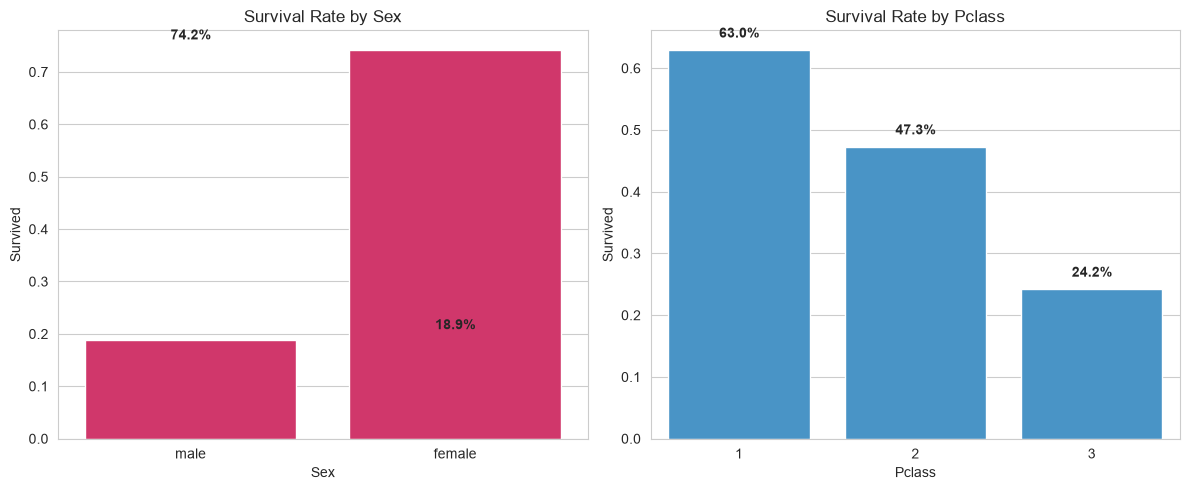

图片已保存到 outputs/figures/


In [7]:
import os
os.makedirs('outputs/figures', exist_ok=True)

# 保存刚才的图（如果你已经跑完前面的图，重新跑一遍并保存）
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=train, x='Sex', y='Survived', ax=axes[0],
            color='#e91e63', errorbar=None)
axes[0].set_title('Survival Rate by Sex')
for i, v in enumerate(train.groupby('Sex')['Survived'].mean().values):
    axes[0].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

sns.barplot(data=train, x='Pclass', y='Survived', ax=axes[1],
            color='#3498db', errorbar=None)
axes[1].set_title('Survival Rate by Pclass')
for i, v in enumerate(train.groupby('Pclass')['Survived'].mean().values):
    axes[1].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(r'C:\Users\Lenovo\Desktop\Titanic-ML\Titanic-ML\outputs\figures\01_survival.png', dpi=150, bbox_inches='tight')
plt.show()

print("图片已保存到 outputs/figures/")

In [8]:
def preprocess(df):
    df = df.copy()
    
    # 1. 填缺失值
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    
    # 2. Cabin 转二值特征
    df['HasCabin'] = df['Cabin'].notna().astype(int)
    
    # 3. 从 Name 提取称呼
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    rare = ['Lady','Countess','Capt','Col','Don','Dr','Major',
            'Rev','Sir','Jonkheer','Dona']
    df['Title'] = df['Title'].replace(rare, 'Rare')
    df['Title'] = df['Title'].replace(['Mlle','Ms'], 'Miss')
    df['Title'] = df['Title'].replace('Mme', 'Mrs')
    
    # 4. 家庭规模
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    
    # 5. 性别编码
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    
    # 6. 独热编码
    df = pd.get_dummies(df, columns=['Embarked', 'Title'], drop_first=True)
    
    return df

train_clean = preprocess(train)
test_clean = preprocess(test)

print("处理后训练集形状:", train_clean.shape)
print("处理后测试集形状:", test_clean.shape)

处理后训练集形状: (891, 20)
处理后测试集形状: (418, 19)


In [9]:
# 选择特征列
feature_cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
                'HasCabin', 'FamilySize', 'IsAlone']
feature_cols += [c for c in train_clean.columns if c.startswith(('Embarked_', 'Title_'))]

X = train_clean[feature_cols]
y = train_clean['Survived']

# 划分验证集
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 训练随机森林
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 评估
preds = model.predict(X_val)
acc = accuracy_score(y_val, preds)
print(f"验证集准确率: {acc:.4f}")

验证集准确率: 0.8212


In [10]:
X_test = test_clean[feature_cols]
predictions = model.predict(X_test)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': predictions
})

submission.to_csv(r'C:\Users\Lenovo\Desktop\Titanic-ML\Titanic-ML\outputs\submission.csv', index=False)
print(f"已保存 submission.csv，共 {len(submission)} 行")
print(submission.head())

已保存 submission.csv，共 418 行
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         1
4          896         0


In [11]:
sub = pd.read_csv(r'C:\Users\Lenovo\Desktop\Titanic-ML\Titanic-ML\outputs\submission.csv')
print("行数:", len(sub))
print("列名:", sub.columns.tolist())
print(sub.head())
print(sub['Survived'].value_counts())

行数: 418
列名: ['PassengerId', 'Survived']
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         1
4          896         0
Survived
0    250
1    168
Name: count, dtype: int64
